# <u>Ridge, Lasso & Elastic Net Regression</u>

### Prerequisites:
* <a href="../2.Multiple%20linear%20Regression/Multiple%20linear%20Regression.ipynb">Check out the notebook on Multiple linear Regression</a>

## Topics

* [Review OLS derivation for Multiple linear Regression](#review)

* [0. Problem with unregularized multiple linear regression](#problem)
    
* [1. Ridge Regression](#ridge)
    * [1.1 Derivation](#derive1)
    * [1.2 Geometry of Ridge Regression](#geom)
    * [1.3 Implementation](#implement1)
    * [1.4 Feature scaling](#scale1)
    * [1.5 Grouping property for correlated Features](#corr1)
    * [1.6 Ridge Regression with polynomial features](#poly)
    * [1.7 Gradient Descent](#gd1)
    * [1.8 Stochastic Gradient Descent](#sgd1)

* [2. Lasso Regression](#lasso)
    * [2.1 Derivation](#derive2)
    * [2.2 Geometry of Lasso Regression](#geom2)
    * [2.3 Implementation](#implement2)
    * [2.4 Feature scaling](#scale2)
    * [2.5 Arbitrary Feature Selection for correlated Features](#corr2)
    * [2.6 Gradient Descent](#gd2)
    * [2.7 Stochastic Gradient Descent](#sgd2)

* [3. Lasso vs Ridge Regression](#lasso)
    * [3.1 L1 Penalty vs L2 Penalty](#L1L2)
    * [3.2 Sparsity (0-Shrinkage) vs Shrinkage](#sparsevsshrink)
    * [3.3 Coefficient Paths](#coeffs)

* [4. Elastic Net Regression](#lasso)
    * [4.1 Motivation](#motivation1)
    * [4.2 Formula](#derive1)
    * [4.3 Implementation](#implement1)

* [5. Robust linear Regression](#robust)

In [205]:
from sklearn.linear_model import Ridge, LinearRegression # library for Ridge Regression taking a fixed lambda value and for OLS
from sklearn.linear_model import RidgeCV # library for Ridge Regression taking an array of lambda values and chooses the best one
from sklearn.preprocessing import PolynomialFeatures, StandardScaler # for preprocessing polynomial features and standardizing features
import statsmodels.api as sm # library for Ridge Regression with statistical inference
import numpy as np # for random numbers and matrix calculus
import plotly.graph_objects as go # interactive 3D plots but more complex
import plotly.express as px # also for interactive 3D plots but more simple
import matplotlib.pyplot as plt # for plotting (mainly 2D)
import pandas as pd # for working with dataframes
from scipy.optimize import minimize # to solve optimization problems (i.e. find parameter vector that minimzes some function but also fulfills a secondary condition)
from sklearn.metrics import mean_squared_error # for mse

<a class="anchor" id="review"></a>
## Review OLS derivation for Multiple linear Regression

In multiple linear regression, we model the relationship between a response variable $y$ and $p$ predictors $X \in \mathbb{R}^{n \times (p+1)}$ using 

$$
y=X\theta + \varepsilon \Leftrightarrow 
\begin{pmatrix}
y^{(1)} \\
y^{(2)} \\
\vdots \\
y^{(n)}
\end{pmatrix} =
\begin{pmatrix}
1 & x_1^{(1)} & \ldots & x_p^{(1)} \\
1 & x_1^{(2)} & \ldots & x_p^{(2)} \\
\vdots & \vdots & \ddots & \vdots \\
1 & x_1^{(n)} & \ldots & x_p^{(n)}
\end{pmatrix}
\begin{pmatrix}
\theta_0 \\
\theta_1 \\
\vdots \\
\theta_p
\end{pmatrix} +
\begin{pmatrix}
\varepsilon^{(1)} \\
\varepsilon^{(2)} \\
\vdots \\
\varepsilon^{(n)}
\end{pmatrix}
$$

We then estimate $\theta$ with $\hat{\theta}$ to make predictions for new data 
$$
\hat{y}=X \hat{\theta}
$$

We can derive the ordinary least squares (OLS) estimator in three ways:
1. Analytical solution (set derivative to 0 and solve)
2. Bayesian statistics
3. Optimization (Gradient Descent)



<div style="display:flex; gap:20px;">

<!--  -->
<div style="
padding:16px;
border-radius:8px;
<!--color:white;-->
width:50%;
">


<h5 style="text-align:center;"><u>Analytical solution</u></h5>

**Goal:** Find parameter vector $\hat{\theta} \in \mathbb{R}^{p+1}$ by finding parameter vector $\theta \in \mathbb{R}^{p+1}$
that minizes sum of squared errors.

$$
\begin{align*}
\hat{\theta} 
&= \arg \min_{\theta \in \mathbb{R}^{p+1}} \lVert y - X\theta \rVert_2^2 \\
&= \arg \min_{\theta \in \mathbb{R}^{p+1}} (y-X\theta)^\top(y-X\theta) \\
&= \frac{\partial}{\partial \theta}  (y - X\theta)^\top (y - X\theta) \\
&= \frac{\partial}{\partial \theta} \left(y^\top y  - 2\theta^\top X^\top y + \theta^\top X^\top X\theta \right) \\
&=  - 2X^\top y + 2 X^\top X\theta 
\end{align*}
$$

Setting the derivative to 0 yields

$$
\begin{align*}
- 2X^\top y + 2 X^\top X\theta &= 0 \\ \Leftrightarrow
2 X^\top X\theta &= 2X^\top y \\ \Leftrightarrow
X^\top X\theta &= X^\top y \\ \Leftrightarrow
(X^\top X)^{-1}X^\top X\theta &= (X^\top X)^{-1}X^\top y \\ \Leftrightarrow
\theta &= (X^\top X)^{-1} X^\top y  \\
\Rightarrow \hat{\theta}_{\text{OLS}} &= (X^\top X)^{-1} X^\top y
\end{align*}
$$



</div>


<!--  -->
<div style="
padding:16px;
border-radius:8px;
<!--color:white;-->
width:50%;
">

<h5 style="text-align:center;"><u>Bayesian statistics</u></h5>

**Goal:** Find parameter vector $\hat{\theta} \in \mathbb{R}^{p+1}$ by finding parameter vector $\theta \in \mathbb{R}^{p+1}$
that maximizes the Posterior distribution $p(\theta \mid y,X)$ over $\theta$.

In the notebook Multiple linear Regression in section <a href="../2.Multiple%20linear%20Regression/Multiple%20linear%20Regression.ipynb#min">Core Minimization problem (OLS)</a> we derive the OLS solution using only the (log) likelihood $p(y \mid X ,\theta)$ but the true general setup includes a prior $p(\theta)$ quantifying our belief of how the true $\theta$ looks like before seeing any data. 

$$
\text{Likelihood: }y \mid X,\theta \sim \mathcal{N}(X\theta, \sigma^2\mathrm{I}_{n\times n}) \text{ since }\varepsilon \sim \mathcal{N}(0, \sigma^2\mathrm{I}_{n\times n}) \\

\text{Prior: } \theta \sim \mathcal{U}(-\infty,\infty)
$$

$$
\begin{align*}
\hat{\theta} 
&= \arg \max_{\theta \in \mathbb{R}^{p+1}} p(\theta \mid y,X) \\
&= \arg \max_{\theta \in \mathbb{R}^{p+1}} \frac{p(y \mid X,\theta)p(\theta)}{p(\mathcal{D})} 
\end{align*}
$$ 

- $\mathcal{D}=\left\{ \left( (x_1^{(i)},x_2^{(i)}, \ldots, x_p^{(i)}),y^{(i)} \right)\right\}_{i=1}^n$ i.i.d.
- $p(\mathcal{D})$ not dependent on $\theta$

$$
\begin{align*}
&= \arg \max_{\theta \in \mathbb{R}^{p+1}} p(y \mid X,\theta)p(\theta)
\end{align*}
$$ 

- $p(\theta) \propto 1$

$$
\begin{align*}
&= \arg \max_{\theta \in \mathbb{R}^{p+1}} p(y \mid X,\theta)
\end{align*}
$$ 

- Taking the logarithm of $p(y \mid X,\theta)$ make calculations more easily and does not change results 
- Also take i.i.d data into account

$$
\begin{align*}
&= \arg \max_{\theta \in \mathbb{R}^{p+1}} \log p(y \mid X,\theta) \\
&= \arg \max_{\theta \in \mathbb{R}^{p+1}} -\frac{n}{2} \log (2\pi\sigma^2) - \frac{1}{2\sigma^2} (y-X\theta)^\top(y-X\theta)
\end{align*}
$$ 

- Since $-\frac{n}{2} \log (2\pi\sigma^2)$ and $\frac{1}{2\sigma^2}$ are independent from $\theta$ and multiplying with $-1$ means we no longer maximize but minimize we get

$$
\begin{align*}
&= \arg \min_{\theta \in \mathbb{R}^{p+1}}  (y-X\theta)^\top(y-X\theta) \\
&= \vdots \\
\Rightarrow \hat{\theta}_{\text{OLS}} &= (X^\top X)^{-1} X^\top y
\end{align*}
$$ 

</div>

</div>



<a class="anchor" id="problem"></a>
## 0. Problems with unregularized multiple linear regression

$$
\hat{\theta}=(X^\top X)^{-1} X^\top y
$$

**This estimator works well under ideal conditions, but in practice unregularized multiple linear regression suffers from several serious problems.**

$$
\begin{align*}
\text{Problems } &=
\left\{ 
\begin{array}{rcl}
\text{Case 1:} & \text{More features than observations } & p > n  \\ 
\text{Case 2:} & \text{Multicollinearity of features } & x_2 \approx 2 \cdot x_1 + \text{small noise}
\end{array}
\right\}
\end{align*}
$$

$$
\begin{align*}
\text{Consequence: } 
& - X^\top X \text{ becomes singular or nearly singular (rank}(X^\top X) < p\text{)} \\
& -\text{Estimated coefficients become very large and unstable} \\
& -\text{Small changes in data cause large changes in estimated coefficients} \\
& -\text{Since features are multicorrelated interpretations of their coefficients are difficult}
\end{align*}
$$

Note:
- Perfect multicollinearity = linear dependence
- Weak/Moderate multicollinearity = near linear dependence

| Case              | $X^TX$          | OLS                   |
| ----------------- | --------------- | --------------------- |
| Linear dependence | singular        | no unique solution    |
| Multicollinearity | nearly singular | unstable/large/non-interpretable coefficients |



#### Case 1A: Multicollinearity

In [4]:
# Case 1A: Multicollinearity
np.random.seed(1841)

n = 50

x1 = np.random.randn(n)
x2 = 2*x1 + 0.01*np.random.randn(n) # almost linear dependent

X = np.c_[np.ones(n), x1, x2]

true_theta = np.array([1, 2, -1])
y = X @ true_theta + 0.2*np.random.randn(n)

# OLS
theta_hat = np.linalg.inv(X.T @ X) @ X.T @ y
print("Estimated coefficients:", theta_hat)

# small noise change
y2 = y + 0.01*np.random.randn(n)
theta_hat2 = np.linalg.inv(X.T @ X) @ X.T @ y2
print("After tiny noise:", theta_hat2)

df_theta = pd.DataFrame({
    "theta_0": [theta_hat[0], theta_hat2[0]],
    "theta_1": [theta_hat[1], theta_hat2[1]],
    "theta_2": [theta_hat[2], theta_hat2[2]],
    "model": ["original fit", "tiny noise fit"]
})

fig = px.scatter_3d(
    df_theta,
    x="theta_0",
    y="theta_1",
    z="theta_2",
    color="model",
    size=[5,5]
)

fig.show()


# scatter points
fig = px.scatter_3d(x=x1, y=x2, z=y)

# grid for planes
grid = np.linspace(x1.min(), x1.max(), 20)
xx, yy = np.meshgrid(grid, grid)

# first plane
zz1 = theta_hat[0] + theta_hat[1]*xx + theta_hat[2]*yy

fig.add_surface(
    x=xx, y=yy, z=zz1,
    opacity=0.5,
    showlegend=True,
    showscale=False,
    name="Fit 1",
    colorscale='Blues'
)

# second plane (after tiny noise)
zz2 = theta_hat2[0] + theta_hat2[1]*xx + theta_hat2[2]*yy

fig.add_surface(
    x=xx, y=yy, z=zz2,
    opacity=0.5,
    showlegend=True,
    showscale=False,
    colorscale=[[0, 'red'], [1, 'red']],
    name="Fit 2 after tiny noise",
)

fig.show()

Estimated coefficients: [ 1.05444392  2.13444852 -1.06249901]
After tiny noise: [ 1.05456105  1.99082407 -0.99017981]


#### Case 1B: Perfect Multicollinearity = Linear dependence

Assume a linear dependence between features:
$$
x_2 = 2x_1
$$

---

**Model:**
$$
\hat{y} = \theta_0 + \theta_1 x_1 + \theta_2 x_2
$$

---

**Substitute the linear dependence:**
$$
\hat{y} = \theta_0 + \theta_1 x_1 + \theta_2 (2x_1)
$$

---

**Simplify:**
$$
\hat{y} = \theta_0 + (\theta_1 + 2\theta_2)x_1
$$

---

**Key observation:**

The prediction depends only on the combination:
$$
\theta_1 + 2\theta_2
$$

---

**Non-uniqueness of the solution:**

Let $c \in \mathbb{R}$. Define a new parameter vector by adding/subtracting from $\theta_1$ and $\theta_2$:
$$
\theta_1'= \theta_1 + (-c)
$$

$$
(\theta_1 - c) + 2(\theta_2 + ?) \text{ and we want } (\theta_1 - c) + 2(\theta_2 + ?) = \theta_1 + 2\theta_2
$$

$$
\begin{align*}
(\theta_1 - c) + 2(\theta_2 + ?) &= \theta_1 + 2\theta_2 \\ \iff 
\theta_1 - c + 2\theta_2 + 2? &= \theta_1 + 2\theta_2 \\ \iff
 - c  + 2? &=  0 \\ \iff
2? &=  c \\ \iff
? &=  \frac{c}{2} \\ \Rightarrow \theta_2'= \theta_2 + \frac{c}{2}
\end{align*}
$$

---

**Check that predictions remain unchanged:**
$$
\theta_1' + 2\theta_2'
= (\theta_1 - c) + 2\left(\theta_2 + \frac{c}{2}\right)
= \theta_1 + 2\theta_2
$$

---

**Conclusion:**
$$
\hat{y}' = \hat{y}
$$

---

**Interpretation:**

- The model is not identifiable.
- Infinitely many parameter vectors yield the same predictions.
- Only $\theta_1$ and $\theta_2$ depend on $x_1$ so only those two can be changed.


In [5]:
# Case 1B: Perfect Multicollinearity = Linear dependence
np.random.seed(1950)

n = 50

x1 = np.random.randn(n)
x2 = 2*x1 # perfect linear dependence

X = np.c_[np.ones(n), x1, x2]

y = 1 + 2*x1 - 1*x2 + 0.1*np.random.randn(n)

# pseudo inverse (since inverse fails)
theta_hat = np.linalg.pinv(X) @ y

print("One valid solution:", theta_hat)

theta_alt = theta_hat.copy()
c = 16 # any number you want
theta_alt[1] -= c
theta_alt[2] += c/2 # keeps prediction identical

print("Alternative solution:", theta_alt)

print("Coefficients identical:",np.allclose(theta_hat,theta_alt))

print("Predictions identical:",np.allclose(X @ theta_hat, X @ theta_alt))

fig = px.scatter_3d(x=x1, y=x2, z=y)

# grid
grid = np.linspace(x1.min(), x1.max(), 20)
xx, yy = np.meshgrid(grid, grid)

# plane 1
zz1 = theta_hat[0] + theta_hat[1]*xx + theta_hat[2]*yy

fig.add_surface(
    x=xx,
    y=yy,
    z=zz1,
    opacity=0.5,
    name="plane 1",
    showscale=False,
    colorscale="Blues",
    showlegend=True
)

# plane 2
zz2 = theta_alt[0] + theta_alt[1]*xx + theta_alt[2]*yy

fig.add_surface(
    x=xx,
    y=yy,
    z=zz2,
    opacity=0.5,
    showscale=False,
    colorscale=[[0, 'red'], [1, 'red']],
    name="plane 2",
    showlegend=True
)

fig.update_layout(
    scene=dict(
        xaxis=dict(range=[-3, 3]),
        yaxis=dict(range=[-6, 6]),
        zaxis=dict(range=[0.9, 1.2])
    )
)

fig.show()

One valid solution: [ 0.98425934 -0.00146873 -0.00293746]
Alternative solution: [  0.98425934 -16.00146873   7.99706254]
Coefficients identical: False
Predictions identical: True


#### Case 2: More features than observations

We consider the case where the number of features exceeds the number of observations:

- $n = 3$ observations
- $p = 5$ features
- Design matrix $X \in \mathbb{R}^{3 \times 6}$ (including intercept)

---

**Linear model:**
$$
y = X \theta + \varepsilon
$$

Since $p+1 > n$, the system is **underdetermined**, i.e., there are infinitely many solutions $\theta$ that satisfy the data.

---

**Minimum-norm OLS solution using pseudo-inverse:**
$$
\hat{\theta} = X^+ y = X^T (X X^T)^+ y
$$

- $X^+$ is the Moore-Penrose pseudo-inverse
- This gives the **unique solution with minimal $| \theta |$** among all possibilities

---

**Alternative solutions:**

Let $v \in \mathbb{R}^{p+1}$ be any vector. We can construct an alternative solution as:

$$
\theta_\text{alt} = \hat{\theta} + \underbrace{v - X^T (X X^T)^+ (X v)}_{\in \text{ null space of } X}
$$

**Check predictions:**
$$
X \theta_\text{alt} = X \hat{\theta} + X \big(v - X^T (X X^T)^+ (X v)\big) = X \hat{\theta}
$$

&#9989; Predictions are identical, even though the coefficients differ.

---

**Connection to the null space:**

- The **null space of \(X\)** is:
$$
\text{null}(X) = \{ z \in \mathbb{R}^{p+1} : X z = 0 \}
$$

- Any vector in the null space **does not change predictions**
- Our alternative solution satisfies:
$$
v_\text{null} = v - X^T (X X^T)^+ (X v) \in \text{null}(X)
$$

- Therefore:
$$
\theta_\text{alt} = \hat{\theta} + v_\text{null}
$$

---

**Interpretation:**

- The system is **underdetermined**, so infinitely many coefficient vectors exist.
- All alternative solutions differ **only along the null space directions** of $X$.
- The pseudo-inverse solution $$\hat{\theta}$$ is the **minimum-norm solution**, while any addition along the null space keeps predictions unchanged.

In [6]:
# Case 2: More features than observations

np.random.seed(0)

n = 3
p = 5

X = np.random.randn(n, p) # design matrix with n rows and p columns and p > n
X = np.c_[np.ones(n), X] # add intercept column

theta_true = np.random.randn(p+1)

y = X @ theta_true + 0.3*np.random.randn(n)

theta_hat = np.linalg.pinv(X) @ y # use np.linalg.pinv(X) instead of np.linalg.inv(X.T @ X)
print("theta=",theta_hat)

v = np.random.randn(p+1) # random vector from standard normal distribution of lenght p+1

theta_alt = theta_hat + v - X.T @ np.linalg.pinv(X @ X.T) @ (X @ v) # alternative solution
print("alternative theta=",theta_alt)

print("Coefficients identical:",np.allclose(theta_hat, theta_alt))
print("Predictions identical:",np.allclose(X @ theta_hat, X @ theta_alt))

theta= [-0.92454478  0.71343054  0.01468797  0.58938041 -0.92772942 -1.14044788]
alternative theta= [-0.453877    0.47280069 -0.45530757  1.11945985 -0.76630576 -1.53596657]
Coefficients identical: False
Predictions identical: True


| Case              | What happens           |
| ----------------- | ---------------------- |
| Multicollinearity | coefficients unstable  |
| Linear dependence | infinite solutions     |
| $p > n$             | infinite solutions     |



<a class="anchor" id="ridge"></a>
## 1. Ridge Regression

<a class="anchor" id="derive1"></a>
## 1.1 Derivation


<div style="display:flex; gap:20px;">

<!--  -->
<div style="
padding:16px;
border-radius:8px;
<!--color:white;-->
width:50%;
">


<h5 style="text-align:center;"><u>Analytical solution</u></h5>

**Goal:** Find parameter vector $\hat{\theta} \in \mathbb{R}^{p'}$ by finding parameter vector $\theta \in \mathbb{R}^{p'}$
that minizes sum of squared errors and <u>shrinks</u> size of coefficients $\theta_1,\ldots,\theta_p$ for $p'= p$ (number of features) (or $\theta_0,\theta_1,\ldots,\theta_p$ for $p'=p+1$;intercept included) via an $\ell_2$ penalty.

**Optimization problem**
$$
\begin{align*}
& \arg \min_{\theta \in \mathbb{R}^{p'}} & \lVert y - X\theta \rVert_2^2 \\
& \text{s.t.} & \lVert \theta \rVert_2^2 \le t   \\
& \iff & \lVert \theta \rVert_2^2 - t \le 0 
\end{align*}
$$

*small $t$ strong restriction $\rightarrow$ heavy shrinkage*

*large $t$ weak restriction $\rightarrow$ close to OLS*



**Lagrangian of optimization problem**

$$
\begin{align*}
\mathcal{L}(\theta,\lambda)
&= \lVert y - X\theta \rVert_2^2 + \lambda (\lVert \theta \rVert_2^2 - t) \hspace{1 mm} \mid \lambda \ge 0 \\
&= (y - X\theta)^\top (y - X\theta) + \lambda (\theta^\top \theta - t) \\
&= y^\top y - y^\top X\theta - (X\theta)^\top y + (X\theta)^\top X\theta + \lambda \theta^\top\theta - \lambda t \\
&= y^\top y - y^\top X\theta - \theta^\top X^\top y + \theta^\top X^\top X\theta + \lambda \theta^\top\theta - \lambda t \\
&= y^\top y - 2\theta^\top X^\top y + \theta^\top X^\top X\theta + \lambda \theta^\top\theta - \lambda t \\
\end{align*}
$$

Take gradient and then set it to 0

$$
\begin{align*}
\nabla_\theta \mathcal{L}(\theta,\lambda) &=0 \\ \Leftrightarrow
- 2 X^\top y + 2X^\top X\theta + 2\lambda \theta  &=0 \\ \Leftrightarrow
- 2 (X^\top y - X^\top X\theta - \lambda \theta)  &=0 \hspace{1 mm} \mid \cdot (-0.5) \\ \Leftrightarrow
X^\top y - X^\top X\theta - \lambda \theta  &=0 \hspace{1 mm} \mid -X^\top y \\ \Leftrightarrow
 - X^\top X\theta - \lambda \theta  &=-X^\top y \hspace{1 mm} \mid \cdot (-1) \\ \Leftrightarrow
X^\top X\theta + \lambda \theta  &=X^\top y\\ \Leftrightarrow
(X^\top X + \lambda I)\theta  &=X^\top y \hspace{1 mm} \mid \cdot (X^\top X + \lambda \mathrm{I})^{-1} \\ \Leftrightarrow
\theta &=(X^\top X + \lambda \mathrm{I})^{-1}X^\top y  \\
\end{align*}
$$
$$
\Rightarrow \hat{\theta}_{\text{Ridge}} =(X^\top X + \lambda \mathrm{I}_{p'\times p'})^{-1}X^\top y 
\text{ for }X\in\mathbb{R}^{n \times p'}  
$$

<p align="center">
<img src="ridge_geom.jpg" width="500"/>
</p>

Relationship between $t$ and $\lambda$:
$$
t \uparrow \Rightarrow \lambda \downarrow 
$$
$$
t \downarrow \Rightarrow \lambda \uparrow
$$



</div>


<!--  -->
<div style="
padding:16px;
border-radius:8px;
<!--color:white;-->
width:50%;
">

<h5 style="text-align:center;"><u>Bayesian statistics</u></h5>

**Goal:** Find parameter vector $\hat{\theta} \in \mathbb{R}^{p'}$ by finding parameter vector $\theta \in \mathbb{R}^{p'}$
that maximizes the Posterior distribution $p(\theta \mid y,X)$ over $\theta$ with $p'=p$(number of features) or $p'=p+1$.



$$
\text{Likelihood: }y \mid X,\theta \sim \mathcal{N}(X\theta, \sigma^2\mathrm{I}_{n\times n}) \text{ since }\varepsilon \sim \mathcal{N}(0, \sigma^2\mathrm{I}_{n\times n}) \\

\text{Prior: } \theta \sim \mathcal{N}(\mu_0=0_{p'}, \tau^2\mathrm{I}_{p'\times p'}) 
$$

$$
\begin{align*}
\hat{\theta} 
&= \arg \max_{\theta \in \mathbb{R}^{p'}} p(\theta \mid y,X) \\
&= \arg \max_{\theta \in \mathbb{R}^{p'}} \frac{p(y \mid X,\theta)p(\theta)}{p(\mathcal{D})} 
\end{align*}
$$ 

- $\mathcal{D}=\left\{ \left( (x_1^{(i)},x_2^{(i)}, \ldots, x_p^{(i)}),y^{(i)} \right)\right\}_{i=1}^n$ 
- $p(\mathcal{D})$ not dependent on $\theta$

$$
\begin{align*}
&= \arg \max_{\theta \in \mathbb{R}^{p'}} p(y \mid X,\theta)p(\theta)
\end{align*}
$$ 


$$
\begin{align*}
p(y \mid X,\theta)
&=\frac{\exp\left(-\frac{1}{2} (y-X\theta)^\top (\sigma^2 \mathrm{I})^{-1}(y-X\theta)\right)}{(2\pi)^{n/2} \det(\sigma^2 \mathrm{I})^{1/2}} \\
&=\frac{\exp\left(-\frac{1}{2} (y-X\theta)^\top (\frac{1}{\sigma^2} \mathrm{I})(y-X\theta)\right)}{(2\pi)^{n/2} (\sigma^{2n})^{1/2}} \\
&=\frac{\exp\left(-\frac{1}{2\sigma^2} (y-X\theta)^\top(y-X\theta)\right)}{(2\pi)^{n/2} \sigma^{n}} \\
&=\frac{\exp\left(-\frac{1}{2\sigma^2} (y-X\theta)^\top(y-X\theta)\right)}{(2\pi \sigma^2)^{n/2}} \\
&=\underbrace{(2\pi \sigma^2)^{-n/2}}_{\text{constant}} \exp\left(-\frac{1}{2\sigma^2} (y-X\theta)^\top(y-X\theta)\right)\\
\end{align*} 
$$

---


$$
\begin{align*}
p(\theta)
&=\frac{\exp\left(-\frac{1}{2} (\theta-\mu_0)^\top (\tau^2 \mathrm{I})^{-1}(\theta-\mu_0)\right)}{(2\pi)^{p'/2} \det(\tau^2 \mathrm{I})^{1/2}} \\
&=\frac{\exp\left(-\frac{1}{2} (\theta-\mu_0)^\top (\frac{1}{\tau^2} \mathrm{I})(\theta-\mu_0)\right)}{(2\pi)^{p'/2} (\tau^{2p'})^{1/2}} \\
&=\frac{\exp\left(-\frac{1}{2\tau^2} (\theta-\mu_0)^\top(\theta-\mu_0)\right)}{(2\pi)^{p'/2} \tau^{p'}} \\
&=\frac{\exp\left(-\frac{1}{2\tau^2} (\theta-\mu_0)^\top(\theta-\mu_0)\right)}{(2\pi\tau^2)^{p'/2}} \\
&=\underbrace{(2\pi \tau^2)^{-p'/2}}_{\text{constant}} \exp\left(-\frac{1}{2\tau^2} (\theta-\mu_0)^\top(\theta-\mu_0)\right)\\
\end{align*} 
$$

---

- terms not depending on $\theta$ are constant with respect to $\theta$ and can be left out here
- Take the logarithm of both $p(y \mid X,\theta)$ and $p(\theta)$ for easier optimization

$$
\begin{align*}
&= \arg \max_{\theta \in \mathbb{R}^{p'}} \log p(y \mid X,\theta)p(\theta) \\
&= \arg \max_{\theta \in \mathbb{R}^{p'}} \log p(y \mid X,\theta) + \log p(\theta) \\
&= \arg \max_{\theta \in \mathbb{R}^{p'}} -\frac{1}{2\sigma^2} \lVert y-X\theta \rVert_2^2 -\frac{1}{2\tau^2} \lVert \theta-\mu_0 \rVert_2^2 \\
&= \arg \min_{\theta \in \mathbb{R}^{p'}} \frac{1}{2\sigma^2} \lVert y-X\theta \rVert_2^2 + \frac{1}{2\tau^2} \lVert \theta-\mu_0 \rVert_2^2 \\
&\text{multiply everything by }2\sigma^2 \text{ for notational convenience} \\
&= \arg \min_{\theta \in \mathbb{R}^{p'}}  \lVert y-X\theta \rVert_2^2 + \frac{\sigma^2}{\tau^2} \lVert \theta-\mu_0 \rVert_2^2 \\
&\hspace{2.5 cm} \text{denote }\lambda := \frac{\sigma^2}{\tau^2} \\
&= \arg \min_{\theta \in \mathbb{R}^{p'}}  \lVert y-X\theta \rVert_2^2 + \lambda \lVert \theta-\mu_0 \rVert_2^2 \\
&= \arg \min_{\theta \in \mathbb{R}^{p'}}  (y-X\theta)^\top (y-X\theta) + \lambda \underbrace{(\theta-\mu_0)^\top (\theta-\mu_0)}_{\theta^\top \theta - \theta^\top \mu_0 - \mu_0^\top \theta + \mu_0^\top \mu_0} \\
\end{align*}
$$ 

* Take gradient and set to 0 
- $- \theta^\top \mu_0 - \mu_0^\top \theta=- \theta^\top \mu_0 - \theta^\top \mu_0=-2\theta^\top \mu_0$

$$
\begin{align*}
-2X^\top y + 2 X^\top X\theta + 2\lambda \theta - 2\lambda\mu_0 &= 0 \hspace{1 mm} \mid \cdot 0.5\\
-X^\top y + X^\top X\theta + \lambda \theta - \lambda\mu_0 &= 0\\
X^\top X\theta + \lambda \theta &= X^\top y + \lambda\mu_0\\
(X^\top X + \lambda \mathrm{I})\theta &= X^\top y + \lambda\mu_0\\
\theta &= (X^\top X + \lambda \mathrm{I})^{-1} (X^\top y + \lambda\mu_0)  \\
\end{align*}
$$ 

$$
\Rightarrow \hat{\theta}_{\text{Ridge}} =(X^\top X + \lambda \mathrm{I}_{p'\times p'})^{-1}X^\top y \hspace{1 mm} \mid \lambda \ge 0 \\[2mm]
\text{ for }X\in\mathbb{R}^{n \times p'}, \mu_0 = 0 \text{ with }0 \in \mathbb{R}^{p'} \\[2mm] \text{ and }\lambda=\frac{\sigma^2}{\tau^2}=\frac{\text{data noise}}{\text{parameter uncertainty}}
$$

- $\lambda=\frac{\sigma^2}{\tau^2}$ is our relative trust in our prior belief about $\theta$
- small $\lambda$ means $\sigma^2 < \tau^2$ which means we have reliable data & unreliable prior beliefs and $\hat{\theta}_{\text{Ridge}}$ is close to $\hat{\theta}_{\text{OLS}}$ **(low shrinakge)**
- large $\lambda$ means $\sigma^2 > \tau^2$ which means we have ureliable data & reliable prior belief and $\hat{\theta}_{\text{Ridge}}$ is close to $\mu_0=0$ **(strong shrinakge)**
- If $\lambda=0$ then $\hat{\theta}_{\text{Ridge}}$ = $\hat{\theta}_{\text{OLS}}$ and $\hat{\theta}_{\text{Ridge}} \rightarrow \mu_0=0$ for $\lambda \rightarrow \infty$ 

</div>

</div>

&#129504; Now how does Ridge solve multicollinearity ? : $X^\top X$ can be non-invertible, but $X^\top X + \lambda \mathrm{I}$ is positive definite and invertible for $\lambda > 0$

&#129504; Ridge Regression is called Ridge Regression because in $(X^\top X + \lambda \mathrm{I})^{-1}X^\top y$ we add positive entries $\lambda \mathrm{I}$ along the diagonal "ridge" of $X^\top X$



<a class="anchor" id="geom1"></a>
## 1.2 Geometry of Ridge Regression

**Optimization problem**
$$
\begin{align*}
& \arg \min_{\theta \in \mathbb{R}^{p'}} & \lVert y - X\theta \rVert_2^2 \\
& \text{s.t.} & \lVert \theta \rVert_2 \le t   \\
\end{align*}
$$

theta_hat= [ 1.87741061 -0.68944138]  this vector minimizes the loss function and is inside the circle


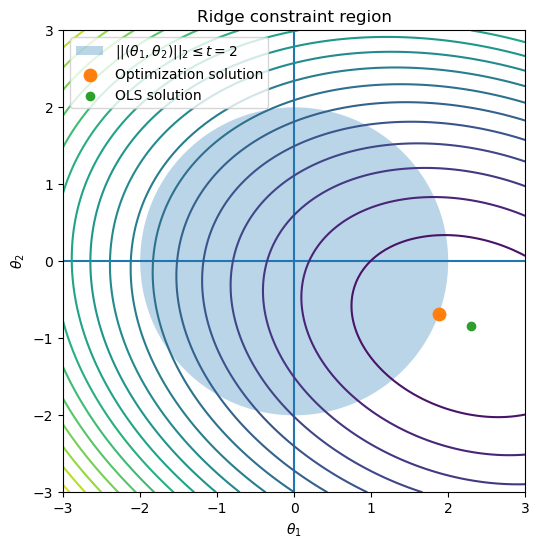

In [7]:
np.random.seed(1126) # for reproducibility of random numbers

# data (NO intercept, 2 parameters)
n, p = 20, 2
X = np.random.randn(n, p)

theta_true = np.array([2.3, -0.8]) # true theta
y = X @ theta_true + 0.2*np.random.randn(n)

# constraint radius
t = 2.0

# objective function (we want to minimize this)
def objective(theta):
    return np.linalg.norm(y - X @ theta)**2

# constraint ||theta|| <= t
cons = ({
    'type': 'ineq', # since we have <= in ||theta|| <= t
    'fun': lambda theta: t - np.linalg.norm(theta) # with t - np.linalg.norm(theta) we can check wether theta is inside the circle 
    # alternative t**2 - np.dot(theta, theta)
})

theta0 = np.zeros(p) # start parameters

res = minimize(objective, theta0, constraints=cons)
#print(res,"\n")
theta_hat = res.x # extract resulting vector

print("theta_hat=", theta_hat," this vector minimizes the loss function and is inside the circle")


# Plot constraint circle
theta = np.linspace(0, 2*np.pi, 400)
theta1 = t * np.cos(theta)
theta2 = t * np.sin(theta)

plt.figure(figsize=(6,6))

# filled circle
plt.fill(theta1, theta2, alpha=0.3, label=f"$ || (\\theta_1,\\theta_2)||_2 \\leq t=2$")

# ridge/optimization solution
plt.scatter(theta_hat[0], theta_hat[1], s=80, label="Optimization solution")

plt.axhline(0)
plt.axvline(0)

plt.xlabel(r"$\theta_1$")
plt.ylabel(r"$\theta_2$")
plt.title("Ridge constraint region")
plt.gca().set_aspect('equal')

# grid for contour
grid = np.linspace(-3, 3, 100)
xx, yy = np.meshgrid(grid, grid)

Z = np.zeros_like(xx)

for i in range(len(grid)):
    for j in range(len(grid)):
        theta_tmp = np.array([xx[i,j], yy[i,j]])
        Z[i,j] = np.linalg.norm(y - X @ theta_tmp)**2

# plot contours
plt.contour(xx, yy, Z, levels=20) # Each contour line connects all points 𝜃 that give the same error with 𝜃_OLS as center
# Moving towards center -> lower error
# Moving away -> higher error


theta_ols = np.linalg.pinv(X) @ y
plt.scatter(theta_ols[0], theta_ols[1], label="OLS solution")
plt.legend(loc=2)


plt.show()

**Lagrangian of the optimization problem**

$$
\hat{\theta}_{\text{Ridge}} =(X^\top X + \lambda \mathrm{I})^{-1}X^\top y
$$

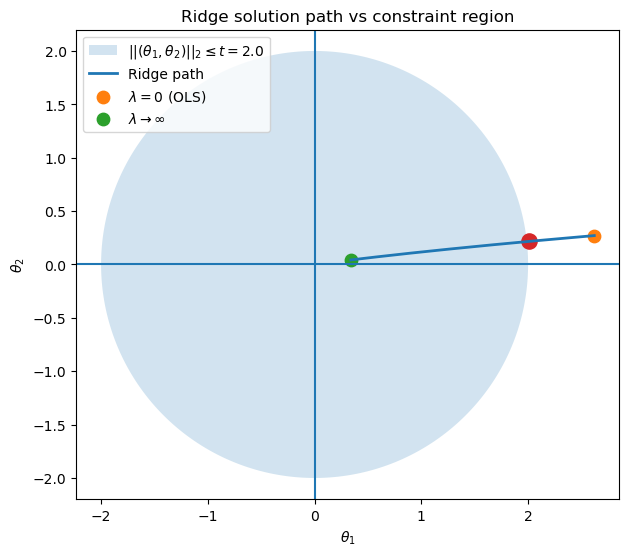

In [8]:
np.random.seed(1127) # for reproducibility of random numbers

# data (NO intercept, 2 parameters)
n, p = 20, 2
X = np.random.randn(n, p)

theta_true = np.array([2.6, 0.3])
y = X @ theta_true + 0.2*np.random.randn(n)

# constraint radius
t = 2.0


# Ridge solutions for lambdas
lambdas = np.linspace(0, 100, 200) # different lambdas

theta_ridge = []

for lam in lambdas:
    theta = np.linalg.inv(X.T @ X + lam*np.eye(p)) @ X.T @ y 
    theta_ridge.append(theta)

theta_ridge = np.array(theta_ridge)


# constraint circle
theta = np.linspace(0, 2*np.pi, 400)
theta1 = t * np.cos(theta)
theta2 = t * np.sin(theta)

plt.figure(figsize=(7,7))

# circle
plt.fill(theta1, theta2, alpha=0.2, label=f"$ || (\\theta_1,\\theta_2)||_2 \\leq t={t}$")

# ridge path
plt.plot(theta_ridge[:,0], theta_ridge[:,1],
         linewidth=2,
         label="Ridge path")

# mark lambda=0 (OLS)
plt.scatter(theta_ridge[0,0],
            theta_ridge[0,1],
            s=80,
            label=r"$\lambda=0$ (OLS)")

# mark large lambda
plt.scatter(theta_ridge[-1,0],
            theta_ridge[-1,1],
            s=80,
            label=r"$\lambda \to \infty$")

plt.axhline(0)
plt.axvline(0)

plt.xlabel(r"$\theta_1$")
plt.ylabel(r"$\theta_2$")
plt.title("Ridge solution path vs constraint region")

plt.legend(loc=2)
plt.gca().set_aspect('equal')

norms = np.linalg.norm(theta_ridge, axis=1) # compute norms of theta_ridge solutions
idx = np.argmin(np.abs(norms - t)) # check for the one theta_ridge that has a norm closest to t

theta_t = theta_ridge[idx] # select that theta_ridge solution

plt.scatter(theta_t[0], theta_t[1],
            s=120,
            label=r"$||\theta|| \approx t$")

plt.show()

**Relationship between $t$ and $\lambda$**

* For every $t$, there exists a $\lambda$ 
* For every $\lambda$, there exists a $t$ 

<u>Steps</u>

1. solve Ridge for different $\lambda$

2. compute $\lVert \theta_{\text{Ridge}} \rVert$ for these different $\lambda$ values

3. pick the $\lVert \theta_{\text{Ridge}} \rVert$ closest to  $t$

Chosen norm: 1.9762381429746485
theta_hat: [1.96481852 0.21214474]
lambda used: 4.9770235643321135


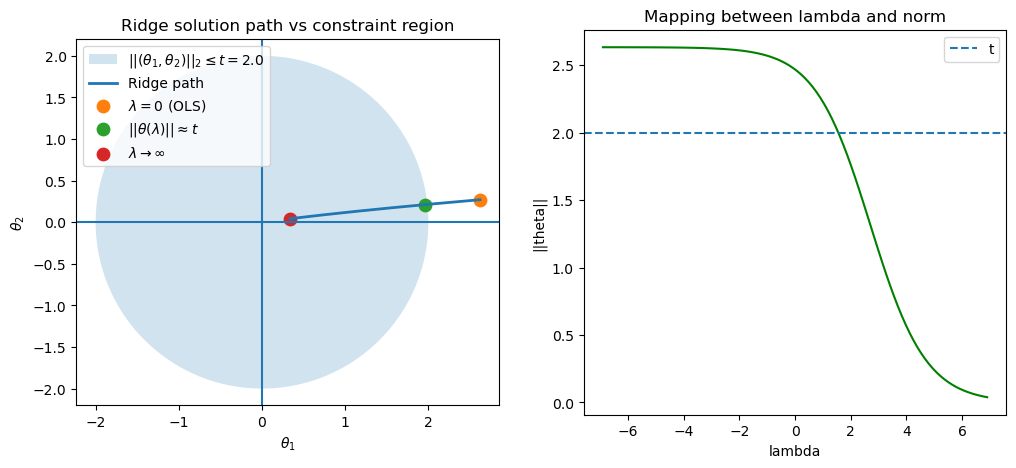

In [9]:
lambdas = np.logspace(-3, 3, 100)

solutions = []
norms = []

for lam in lambdas:
    theta = np.linalg.inv(X.T @ X + lam*np.eye(X.shape[1])) @ X.T @ y
    solutions.append(theta)
    norms.append(np.linalg.norm(theta))

# find closest to desired t
t = 2.0
idx = np.argmin(np.abs(np.array(norms) - t)) # find theta_ridge solution closest to t

theta_hat = solutions[idx]

print("Chosen norm:", norms[idx])
print("theta_hat:", theta_hat)
print("lambda used:", lambdas[idx])


plt.figure(figsize=(12,5))
plt.subplot(1,2,1)

# circle
plt.fill(theta1, theta2, alpha=0.2, label=f"$ || (\\theta_1,\\theta_2)||_2 \\leq t={t}$")

# ridge path
plt.plot(theta_ridge[:,0], theta_ridge[:,1],
         linewidth=2,
         label="Ridge path")

# mark lambda=0 (OLS)
plt.scatter(theta_ridge[0,0],
            theta_ridge[0,1],
            s=80,
            label=r"$\lambda=0$ (OLS)")

# mark lambda closest to t
plt.scatter(theta_hat[0],
            theta_hat[1],
            s=80,
            label=r"$||\theta(\lambda)|| \approx t$")

# mark large lambda
plt.scatter(theta_ridge[-1,0],
            theta_ridge[-1,1],
            s=80,
            label=r"$\lambda \to \infty$")

plt.axhline(0)
plt.axvline(0)

plt.xlabel(r"$\theta_1$")
plt.ylabel(r"$\theta_2$")
plt.title("Ridge solution path vs constraint region")
plt.legend(loc=2)
plt.gca().set_aspect('equal')

plt.subplot(1,2,2)
plt.plot(np.log(lambdas), norms,color="green")
plt.axhline(t, linestyle='--',label="t")
#plt.xscale('log')
plt.xlabel("lambda")
plt.ylabel("||theta||")
plt.title("Mapping between lambda and norm")


plt.legend(loc=1)
plt.show()

**Generalized L2 Regularization = Ridge Regression with $\mu_0$ $\neq$ 0**

$$
\hat{\theta}_{\text{Ridge}} =(X^\top X + \lambda \mathrm{I})^{-1} (X^\top y + \lambda \mu_0)
$$

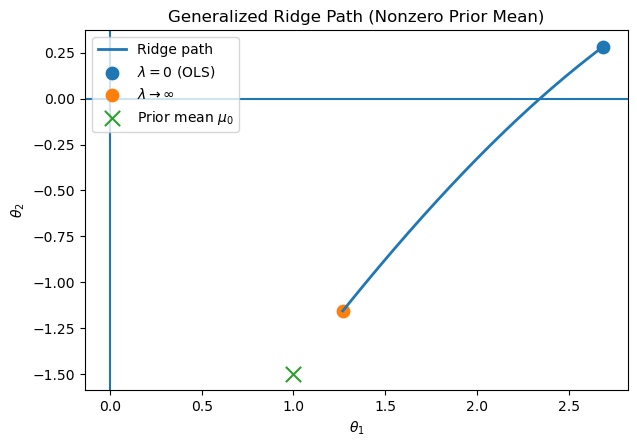

In [164]:
np.random.seed(1720) # for reproduicibility of random numbers

# Data (NO intercept, 2 parameters)
n, p = 20, 2
X = np.random.randn(n, p)

theta_true = np.array([2.6, 0.3])
y = X @ theta_true + 0.2 * np.random.randn(n)

mu0 = np.array([1.0, -1.5]) # Prior mean (NOT zero!)

lambdas = np.linspace(0, 100, 200) # lambda values and ridge path

theta_ridge = []

for lam in lambdas:
    theta = np.linalg.inv(X.T @ X + lam * np.eye(p)) @ (X.T @ y + lam * mu0)
    theta_ridge.append(theta)

theta_ridge = np.array(theta_ridge)

# Plot
plt.figure(figsize=(7,7))

# Ridge path
plt.plot(theta_ridge[:,0], theta_ridge[:,1],
         linewidth=2,
         label="Ridge path")

# OLS (lambda = 0)
plt.scatter(theta_ridge[0,0],
            theta_ridge[0,1],
            s=80,
            label=r"$\lambda=0$ (OLS)")

# Large lambda -> prior mean
plt.scatter(theta_ridge[-1,0],
            theta_ridge[-1,1],
            s=80,
            label=r"$\lambda \to \infty$")

# Prior mean (target of shrinkage)
plt.scatter(mu0[0], mu0[1],
            s=120,
            marker="x",
            label=r"Prior mean $\mu_0$")

# axes
plt.axhline(0)
plt.axvline(0)

plt.xlabel(r"$\theta_1$")
plt.ylabel(r"$\theta_2$")
plt.title("Generalized Ridge Path (Nonzero Prior Mean)")

plt.legend(loc=2)
plt.gca().set_aspect('equal')

plt.show()

<a class="anchor" id="implement1"></a>
## 1.3 Implementation 

```python
# 1. Ridge (scikit-learn)
from sklearn.linear_model import Ridge
model1 = Ridge(
    alpha=1.0,              # λ (regularization strength)
    fit_intercept=True,     # whether to estimate intercept θ0
    copy_X=True,            # copy X or overwrite
    max_iter=None,          # max iterations (only relevant for some solvers)
    tol=1e-4,               # convergence tolerance
    solver="auto",          # solver chosen automatically
    positive=False,         # force coefficients >= 0 if True
    random_state=None       # used for stochastic solvers
)

model1.fit(X, y) # fit model (solve Ridge optimization problem)

model1.coef_        # estimated slope coefficients θ1,...,θp (shape: (p,))
model1.intercept_   # estimated intercept θ0
model1.predict(X)   # predictions
model1.score(X, y)  # R^2 score
model1.n_features_in_   # number of features
model1.feature_names_in_  # feature names (if X is pandas DataFrame)


# 2. Ridge with Cross-Validation
model2 = RidgeCV(
    alphas=np.logspace(-3, 3, 100),  # candidate λ values
    fit_intercept=True,
    scoring=None,        # scoring metric (None = default R^2)
    cv=None,             # None = efficient LOOCV (Leave-one-out CV)
    gcv_mode=None,       # mode for generalized CV
    store_cv_values=False,  # must be True to access cv_values_
    alpha_per_target=False  # separate λ per target (multi-output only)
)

model2.fit(X, y)  # fits model AND selects best λ

model2.alpha_      # best λ found via CV
model2.coef_       # coefficients
model2.intercept_  # intercept
model2.predict(X)  # predictions


# ⚠️ Only available if store_cv_values=True
model2.cv_values_  # shape: (n_samples, n_alphas)

# 3. Ridge via statsmodels
import statsmodels.api as sm

X_sm = sm.add_constant(X) # Add intercept manually 

model3 = sm.OLS(y, X_sm) # create OLS model object

results_ridge = model3.fit_regularized(
    alpha=1.0, # λ
    L1_wt=0 # 0 -> pure L2 penalty (Ridge)
)

results_ridge.params # coefficients INCLUDING intercept (first element)

y_pred = X_sm @ results_ridge.params # predictions (must be done manually)

results_lasso = model3.fit_regularized(
    alpha=1.0, # λ
    L1_wt=1 # 1 -> pure L1 penalty (Lasso)
)

results_lasso.params # coefficients INCLUDING intercept (first element)

```

```python
from sklearn.linear_model import Ridge
model1 = Ridge(
    alpha=1.0,           
    fit_intercept=True,    
    copy_X=True,          
    max_iter=None,       # max iterations (only relevant for some solvers)
    tol=1e-4,            # convergence tolerance
    solver="auto",       # solver chosen automatically
    positive=False,         
    random_state=None    # used for stochastic solvers
)
```
### ``solver`` $-$ How the optimization is actually solved

Ridge regression has a closed-form solution:$$(X^\top X + \lambda \mathrm{I})^{-1} X^\top y$$
But in practice, we don't always compute this directly. The **solver** decides how we compute $\hat{\theta}$

#### &#128273; Available solvers in Ridge

<div style="display:flex; gap:20px;">

<!--  -->
<div style="
padding:16px;
border-radius:8px;
width:50%;
">

##### 1. ``svd`` (Singular Value Decomposition)

- Most numerically stable
- Handles multicollinearity very well
- Slower

&#128073; Best for
- $X^\top X$ close to singular
- stability over speed


##### 2. ``cholesky`` 

- Uses matrix factorization of $X^\top X$
- Very fast
- Less stable than SVD

&#128073; Best for
- well conditioned data
- small/medium datasets

</div>


<!--  -->
<div style="
padding:16px;
border-radius:8px;
width:50%;
">

##### 3. ``lsqr`` 

- Iterative solver
- Does NOT compute inverse

&#128073; Best for
- large datasets

##### 4. ``sag`` (Stochastic Average Gradient) 

- Uses gradient descent
- Needs scaling!
- Fast for large datasets

&#128073; Best for
- large datasets
- speed required


</div>
<div style="
padding:16px;
border-radius:8px;
width:50%;
">

##### 5. ``saga`` 

- Improved version of SAG
- Works for L1 + L2 (Elastic Net)
- Handles sparse data

##### 6. ``auto`` 

- sklearn picks the best solver automatically

</div>
</div>

#### &#129504; Intuition

* Small data $\rightarrow$ exact linear algebra (``svd``, ``cholesky``)
* Large data $\rightarrow$ iterative optimization (``sag``, ``lsqr``)

---

### ``max_iter`` $-$ How long we allow iterative solvers to run

Only relevant for:

- ``sag``
- ``saga``
- ``lsqr``
#### &#128273; Meaning

```python
    max_iter = number of iterations
```

Each iteration:
- updates $\theta$ 
- moves closer to the minimum

#### &#129504; Intuition: "How many steps of gradient descent am I willing to take?"

Right choice of ``max_iter``:
- ``max_iter`` to small $\rightarrow$ algorithm stops early and solution not optimal
- ``max_iter`` to large $\rightarrow$ solution more accurate

---

### ``tol`` $-$ When to stop optimizing

#### &#128273; Meaning
Stop when
$$
\text{change in solution } < \text{ tol}
$$
or equivalently
$$
\lVert \theta^{(k)} - \theta^{(k-1)} \rVert < \text{ tol} 
$$

Each iteration:
- updates $\theta$ 
- moves closer to the minimum

#### &#129504; Intuition
- Small ``tol`` $\rightarrow$ very precise solution
- Large ``tol`` $\rightarrow$ faster but rougher solution

---

### ``random_state`` $-$ Reproducibility

Only relevant for:
- ``sag``
- ``saga``

#### &#128273; Why randomness exists
These solvers:
- pick random subsets of data
- update parameters using stochastic gradients

#### &#129504; Intuition
```python
    random_state = 42
```

&#128073; ensures:
- same random numbers
- same training result every run

## &#129504; Big Picture

| Parameter      | Role                              |
| -------------- | --------------------------------- |
| `solver`       | **how** we solve the optimization |
| `max_iter`     | **how long** we solve             |
| `tol`          | **how precise** we solve          |
| `random_state` | **reproducibility**               |


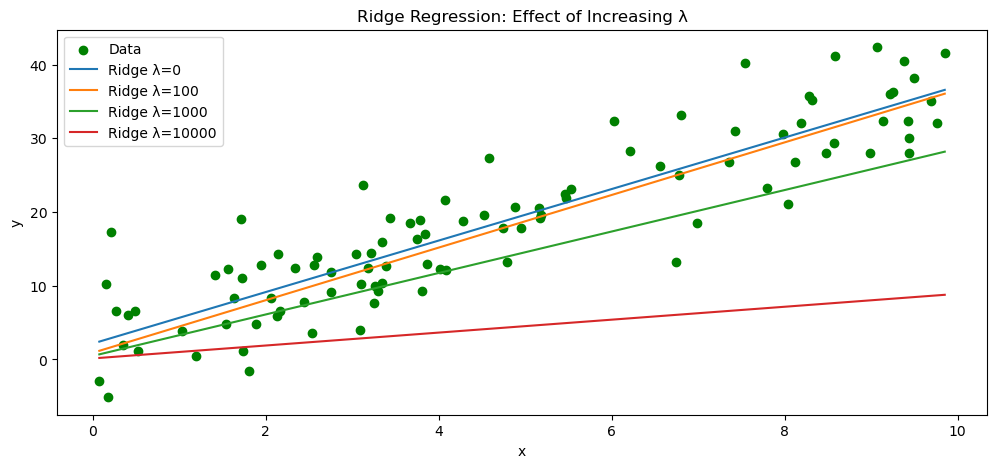

In [ ]:
# Data
np.random.seed(1134)
n = 100
x = np.random.uniform(0, 10, n)
X = np.column_stack((np.ones(n),x))

true_theta = np.array([2,3.5])
y = X @ true_theta + np.random.randn(n) * 5

# OLS
#ols = LinearRegression(fit_intercept=False).fit(X, y)

# Ridge models with increasing lambda
lambdas = [0,100,1000, 10000]
ridge_models = [Ridge(alpha=l, fit_intercept=False).fit(X, y) for l in lambdas]

# Grid for plotting
x_line=np.linspace(x.min(), x.max(), 100)
x_grid = np.column_stack((np.ones(len(x_line)),x_line))

# Plot
plt.figure(figsize=(12,5))

# Scatter data
plt.scatter(x, y, label="Data",color="green")

# OLS line
#plt.plot(x_line, ols.predict(x_grid), label="OLS", linewidth=2)

# Ridge lines
for l, model in zip(lambdas, ridge_models):
    plt.plot(x_line, model.predict(x_grid), label=f"Ridge λ={l}")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Ridge Regression: Effect of Increasing λ")
plt.legend()
plt.show()

In [55]:
# Generate data
np.random.seed(1134) # for reproduicibility of random numbers
n = 100 # number of observations
x1 = np.random.uniform(0,10,n) # first feature
x2 = 1.5 * x1 + 5*np.random.rand(n) # second feature is correlated to first one
print("Correlation between x1 and x2:\n",np.corrcoef(x1, x2))
X = np.column_stack((x1,x2))
error = np.random.randn(n) * 10
true_theta = np.array([1.4,0.6])
y = X @ true_theta + error

# OLS 
model_OLS = LinearRegression(fit_intercept=False).fit(X,y)
print("Estimated OLS coefficients with library:",model_OLS.coef_)
theta_hat = np.linalg.pinv(X) @ y # more numerically stable than np.linalg.inv(X.T @ X) @ X.T @ y
print("Estimated OLS coefficients analytically:",theta_hat)

# Ridge
lbda=100
model_ridge = Ridge(alpha=lbda,fit_intercept=False).fit(X,y)
print("Estimated Ridge coefficients with library:",model_ridge.coef_," with lbda=",lbda)
I = np.eye(X.shape[1])
theta_hat = np.linalg.pinv(X.T @ X + lbda * I) @ X.T @ y
print("Estimated OLS coefficients analytically:",theta_hat," with lbda=",lbda)



# Create grid
x1_grid = np.linspace(x1.min(), x1.max(), 30)
x2_grid = np.linspace(x2.min(), x2.max(), 30)
x1_mesh, x2_mesh = np.meshgrid(x1_grid, x2_grid)

X_grid = np.column_stack([x1_mesh.ravel(), x2_mesh.ravel()])

# Predictions
y_ols = model_OLS.predict(X_grid).reshape(x1_mesh.shape)
y_ridge = model_ridge.predict(X_grid).reshape(x1_mesh.shape)

# Plot
fig = px.scatter_3d(x=x1,y=x2,z=y,labels={"x":"x1","y":"x2","z":"y"},title="Ridge vs OLS")

# Scatter data but with go
#fig.add_trace(go.Scatter3d(
#    x=x1, y=x2, z=y,
#    mode='markers',
#    marker=dict(size=4),
#    name='Data'
#))

# OLS surface
fig.add_trace(go.Surface(
    x=x1_mesh, y=x2_mesh, z=y_ols,
    opacity=0.5,
    name='OLS Surface',
    showscale=False,
    showlegend=True,
    colorscale="Blues"
))

# Ridge surface
fig.add_trace(go.Surface(
    x=x1_mesh, y=x2_mesh, z=y_ridge,
    opacity=0.5,
    name='Ridge Surface',
    showscale=False,
    showlegend=True,
    colorscale="Greens"
))

fig.update_layout(
    title="OLS vs Ridge Regression Surfaces",
    scene=dict(
        xaxis_title='x1',
        yaxis_title='x2',
        zaxis_title='y'
    )
)

fig.show()

Correlation between x1 and x2:
 [[1.         0.95362394]
 [0.95362394 1.        ]]
Estimated OLS coefficients with library: [ 3.29225466 -0.30663986]
Estimated OLS coefficients analytically: [ 3.29225466 -0.30663986]
Estimated Ridge coefficients with library: [1.71840716 0.48989784]  with lbda= 100
Estimated OLS coefficients analytically: [1.71840716 0.48989784]  with lbda= 100


#### Important Side Note:

In Practice (using sklearn) if the Ridge Regression model includes an intercept term $\theta_0$ then this it is excluded from regularization so that the "infinetly" regularized model is the constant model .

This means that inside $(X^\top X + \lambda \mathrm{I})^{-1} X^\top y$ instead of using

$$
\mathrm{I} = \begin{pmatrix} 1 & 0 & \ldots & 0 \\ 0 & 1 & \ldots & 0 \\ \vdots & \vdots & \ddots & \vdots \\ 0 & 0 & \ldots & 1 \end{pmatrix}
$$

sklearn uses:

$$
\mathrm{I} = \begin{pmatrix} 0 & 0 & \ldots & 0 \\ 0 & 1 & \ldots & 0 \\ \vdots & \vdots & \ddots & \vdots \\ 0 & 0 & \ldots & 1 \end{pmatrix} 
$$
&#128073; The first diagonal element $\mathrm{I}_{0,0}$ is 0, so the intercept is not penalized.



<div style="display:flex; gap:20px;">

<!--  -->
<div style="
padding:16px;
border-radius:8px;
width:50%;
">

##### Why this is done
Penalizing the intercept would:
- Shift predictions up or down unnecessarily
- Depend on the data's mean (which is arbitrary)

&#128073; The intercept is meant to capture the baseline level, not be shrunk.



</div>


<!--  -->
<div style="
padding:16px;
border-radius:8px;
width:50%;
">



##### How sklearn actually implements it
Internally:
- The model centers the data $y$
- Then solves the ridge problem without penalizing the intercept
- The regularization is applied only to the coefficients $\theta_1,...,\theta_p$


</div>
</div>


<a class="anchor" id="scale1"></a>
## 1.4 Feature Scaling 

### Key idea
Regularized models penalize the **size of coefficients**, so the scale of input features directly affects the penalty.

---

### OLS vs Regularized Models


<div style="display:flex; gap:20px;">

<!--  -->
<div style="
padding:16px;
border-radius:8px;
width:50%;
">

**OLS**  
$$
  \sum (y_i - \hat{y}_i)^2
$$ 
  - No penalty on coefficients  
  - Scaling features does **not change predictions** (only rescales coefficients)



</div>


<!--  -->
<div style="
padding:16px;
border-radius:8px;
width:50%;
">

**Ridge**  
$$
  \sum (y_i - \hat{y}_i)^2 + \lambda \sum \theta_j^2
$$

**Lasso**  
$$
  \sum (y_i - \hat{y}_i)^2 + \lambda \sum |\theta_j|
$$



</div>
</div>

---

### The scaling problem

If features are on different scales:

- A **large-scale feature** (e.g., values in thousands) requires a **small coefficient**
- A **small-scale feature** (e.g., values between 0 and 1) requires a **large coefficient**

Since regularization penalizes the **size of coefficients**, this leads to:

- Large-scale features → **less penalized**
- Small-scale features → **more penalized**

&#128073; Without scaling, the model is biased toward features with larger numeric ranges, not on actual importance.

---

### Example intuition

Suppose two equally important features:

- Small scale Feature A is measured in meters (values like 0–10)
- Large scale Feature B is measured in millimeters (values like 0–10.000)

To achieve the same effect:
- Small scale Feature A (i.e. $x_1$=5m) $\rightarrow$ $\theta_1$ must be large to counteract
- Large scale Feature B (i.e. $x_2$=5000mm) $\rightarrow$ $\theta_2$ must be small to counteract

Under Ridge/Lasso:
- Feature A gets **penalized more**
- Feature B gets **penalized less**

&#128073; The model unfairly prefers one feature over the other purely due to scale.

---

### Solution: Feature scaling

To ensure fair regularization standardize features:

$$
  x_j \leftarrow \frac{x_j - \mu_j}{\sigma_j}
$$

This gives all features:
- Mean = 0
- Standard deviation = 1

&#128073; Now all coefficients are on the same magnitud and are comparable, so the penalty is applied fairly.

---

### Key takeaway

For regularized models:
- **Always scale your features before training**
- This ensures the penalty reflects **true importance**, not feature units

---

## Rescaling equivalence in unregularized models

In **OLS**, the objective is:

$$
\sum (y_i - \hat{y}_i)^2
$$

There is **no penalty term**, so:

- If a feature is rescaled, its coefficient simply adjusts inversely
- Predictions remain unchanged

👉 Example:
- If $x_j$ is multiplied by 10, then $\theta_j$ becomes $1/10$
- The product $\theta_j x_j$ stays the same

👉 OLS is **rescaling invariant (equivariant)**  
👉 Feature scaling does **not affect model performance**, only coefficient interpretation

---

### Key takeaway for OLS

- Feature scaling is **not required**
- It does **not affect predictions**
- It only changes the **interpretation of coefficients**

---

## Final summary 

| Aspect | OLS | Ridge/Lasso/Elastic Net |
|------|-----|----------------|
| Uses penalty | ❌ No | ✅ Yes |
| Sensitive to feature scale | ❌ No | ✅ Yes |
| Need to scale features | ❌ Optional | ✅ Essential |
| Effect of scaling | Only changes coefficients | Affects model behavior |



```python
from sklearn.preprocessing import StandardScaler # used to standardize features by removing the mean and scaling to unit variance

X = np.array([[1, 2], [3, 4], [5, 6]]) # data matrix of shape (n_samples, n_features)
# array([[1, 2],
#       [3, 4],
#       [5, 6]])

scaler = StandardScaler(copy=True,with_mean=True,with_std=True) # create a sklearn.preprocessing._data.StandardScaler object
# with_mean -> Whether centering is applied
# with_std -> Whether scaling is applied
# copy -> Copy or in-place transform

scaler.fit(X) # Standarscaler learns the statistics of X and computes mean and variance/std of each feature

scaler.mean_ # returns an arry of shape (n_features,) with the mean of each feature (only available if with_mean=True)
scaler.var_ # returns an arry of shape (n_features,) with the variance of each feature (Used to compute the standard deviation)
scaler.scale_ # returns an arry of shape (n_features,) with the standard deviation (only available if with_std=True and if variance is zero then scale is set to 1 to avoid division by zero)
scale.n_features_in_ # number of features seen during fit()
scale.feature_names_in_ # returns an arry of shape (n_features,) with names of features (only if input has column names, e.g. pandas DataFrame)
scale.n_samples_seen_ # Number of samples processed
X_scaled = scaler.transform(X) # applies standardization: X_scaled = (X - mean_) / scale_
X_scaled = scaler.fit_transform(X) # shortcut
```

In [232]:
np.random.seed(1418) # for reproduicibility of random numbers

n = 200 # Sample size

theta_true = np.arange(1,6) # True parameters

X = np.random.randn(n, 5) # Generate features (5 features with no itercept)

eps = np.random.normal(0, 1, n) # Generate noise

y = X @ theta_true + eps # Generate target

# Custom MSE
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)


# OLS
ols = LinearRegression(fit_intercept=False)
ols.fit(X, y)

theta_hat = ols.coef_
y_pred = ols.predict(X)

print("OLS coefficients:", np.round(theta_hat, 3))
print("MSE:", round(mean_squared_error(y, y_pred), 3))


# OLS with rescaled x5
X_rescaled = X.copy()
X_rescaled[:, 4] *= 100

ols_rescaled = LinearRegression(fit_intercept=False)
ols_rescaled.fit(X_rescaled, y)

theta_hat_rescaled = ols_rescaled.coef_
y_pred_rescaled = ols_rescaled.predict(X_rescaled)

print("\nOLS after rescaling x5:")
print("Coefficients:", np.round(theta_hat_rescaled, 3))
print("MSE stays the same:", round(mse(y, y_pred_rescaled), 3))

print(f"As we can see only theta_5={np.round(theta_hat_rescaled[4],3)} "
      f"gets scaled by 1/100 and can be anti-scaled to "
      f"{np.round(theta_hat_rescaled[4]*100,3)}")


# Ridge (lambda = 10)
ridge = Ridge(alpha=10, fit_intercept=False)
ridge.fit(X, y)

theta_ridge = ridge.coef_
y_pred_ridge = ridge.predict(X)

print("\nRidge coefficients:", np.round(theta_ridge, 3))
print("MSE:", round(mse(y, y_pred_ridge), 3))


# Ridge with rescaled x5
ridge_rescaled = Ridge(alpha=10, fit_intercept=False)
ridge_rescaled.fit(X_rescaled, y)

theta_ridge_rescaled = ridge_rescaled.coef_
y_pred_ridge_rescaled = ridge_rescaled.predict(X_rescaled)

print("\nRidge after rescaling x5:")
print("Coefficients:", np.round(theta_ridge_rescaled, 3))
print("MSE stays the same:", round(mean_squared_error(y, y_pred_ridge_rescaled), 3))
print(
"\nRescaling x_5 changes the ridge solution: since x_5 becomes large in scale, \n"
"theta_5 shrinks significantly. Because the L2 penalty treats all coefficients equally, \n"
"this alters the balance of the optimization, causing the other coefficients to adjust \n"
"(sometimes increasing) rather than remaining invariant as in OLS."
)

OLS coefficients: [0.965 2.045 3.089 3.985 4.895]
MSE: 1.151

OLS after rescaling x5:
Coefficients: [0.965 2.045 3.089 3.985 0.049]
MSE stays the same: 1.151
As we can see only theta_5=0.049 gets scaled by 1/100 and can be anti-scaled to 4.895

Ridge coefficients: [0.904 1.967 2.926 3.826 4.629]
MSE: 1.277

Ridge after rescaling x5:
Coefficients: [0.907 1.959 2.935 3.811 0.049]
MSE stays the same: 1.218

Rescaling x_5 changes the ridge solution: since x_5 becomes large in scale, 
theta_5 shrinks significantly. Because the L2 penalty treats all coefficients equally, 
this alters the balance of the optimization, causing the other coefficients to adjust 
(sometimes increasing) rather than remaining invariant as in OLS.


Manual vs Library equal: True


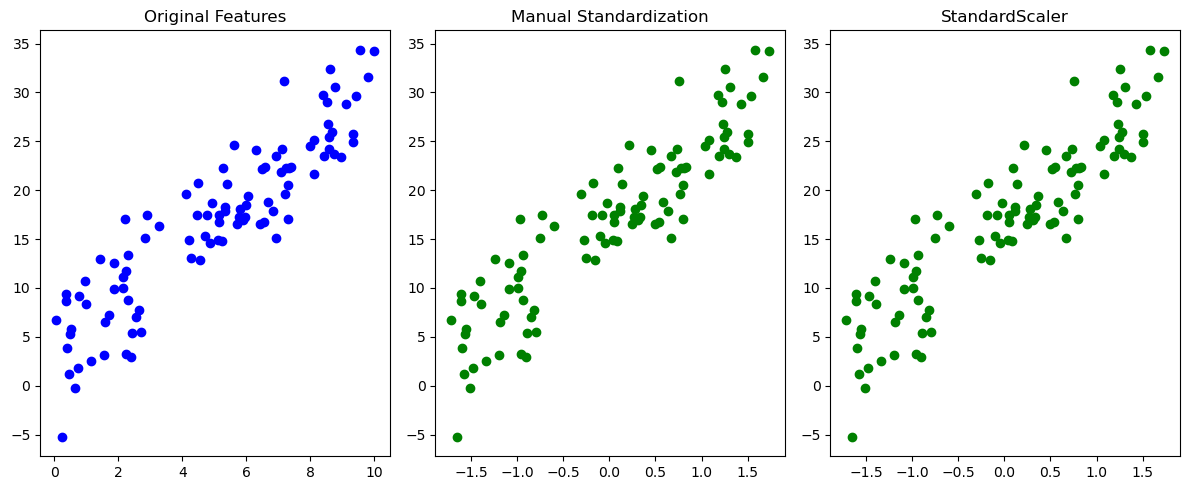

In [ ]:
def standard(X):
    """
    Standardizes features with mean and standard deviation
    Input:
        - array X of shape (n,p) with n=number of observations and p=number of features (no intercept column)
    Output:
        - array X with standardized values per column
    """
    feature_means = np.mean(X, axis=0) # mean per column
    feature_std = np.std(X, axis=0) # variance per column
    feature_std[feature_std == 0] = 1 # avoid division by 0
    return (X - feature_means) / feature_std


np.random.seed(1320)
n = 100

X_features = np.random.uniform(0, 10, (n, 1))
X_design = np.c_[np.ones(n), X_features]

theta_true = np.random.uniform(0, 5, X_design.shape[1])
y = X_design @ theta_true + np.random.normal(0, 3.5, n)

# Standardize
X_stand_manual = standard(X_features)
from sklearn.preprocessing import StandardScaler
X_stand_lib = StandardScaler().fit_transform(X_features)


print("Manual vs Library equal:", np.allclose(X_stand_manual, X_stand_lib)) # Check equality

# Plot
plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
plt.scatter(X_features, y, color="blue")
plt.title("Original Features")

plt.subplot(1,3,2)
plt.scatter(X_stand_manual, y, color="green")
plt.title("Manual Standardization")

plt.subplot(1,3,3)
plt.scatter(X_stand_lib, y, color="green")
plt.title("StandardScaler")

plt.tight_layout()
plt.show()

<a class="anchor" id="corr1"></a>
## 1.5 Grouping property for correlated Features 

**Grouping property:** 

$\quad$ In Ridge regression, strongly correlated features get similar coefficients (they are "grouped" together) because the L2 penalty

**Why:** 

$\quad$ The penalty term $\lambda \sum \theta_j^2$ shrinks coefficients smoothly, so correlated variables share the effect instead of one dominating.

**Example:**

$\quad$ If $x_1 \approx x_2$ (highly correlated), instead of
$$
\theta_1 = 2, \theta_2=0
$$
$\quad$ Ridge tends for large $\lambda$ toward
$$
\theta_1 \approx 1, \theta_2 \approx 1
$$

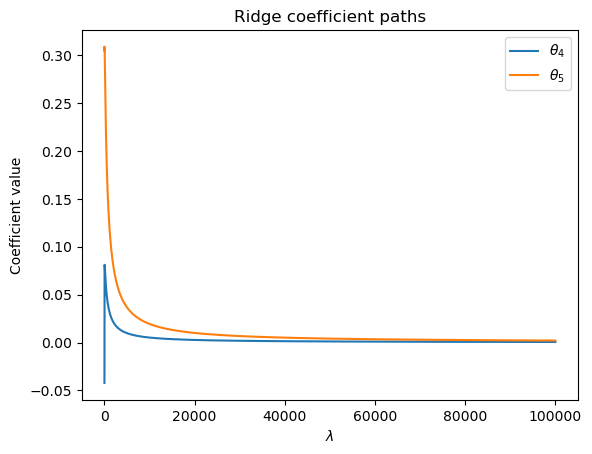

In [280]:
# Generate data
np.random.seed(1728)
n = 100
X = np.random.rand(n,3)
x4 = np.random.rand(n)
x5 = 2.1*x4 + np.random.uniform(0,2,n) # x4 and x5 highly correlated
X = np.c_[X,x4,x5]
error = np.random.randn(n) * 0.5
true_theta = np.ones(X.shape[1])*0.2
y = X @ true_theta + error

lambdas = np.arange(0,100000,10) 
coefs = []

for lam in lambdas:
    ridge = Ridge(alpha=lam, fit_intercept=False)
    ridge.fit(X, y)
    coefs.append(ridge.coef_)

coefs = np.array(coefs)

# Plot all coefficient paths
plt.figure()
for j in range(3,coefs.shape[1]): # only focus on theta_4 and theta_5
    plt.plot(lambdas, coefs[:, j], label=fr'$\theta_{j+1}$')

plt.xlabel(r'$\lambda$')
plt.ylabel('Coefficient value')
plt.title('Ridge coefficient paths')
plt.legend()
plt.show()
    

<a class="anchor" id="poly"></a>
## 1.6 Ridge Regression with polynomial features 

We assume the following model:

$$
y^{(i)} = \sum_{k=0}^{d} \theta_k \, \phi_k(x^{(i)}) + \varepsilon^{(i)}
\hspace{2mm} \text{for } i = 1, \dots, n
$$
with
$$
\phi^{(d)}: \mathbb{R} \rightarrow \mathbb{R}^{d+1}, x \mapsto [\phi_0(x),\phi_1(x),\phi_2(x),...,\phi_d(x)]^\top=[x^0,x^1,x^2,...,x^d]^\top=[1,x,x^2,..,x^d]^\top
$$
resulting in
$$
y^{(i)} = \theta_0 + \theta_1 \cdot x^{(i)} + \ldots + \theta_d (x^{(i)})^d + \varepsilon^{(i)}
\hspace{2mm} \text{for } i = 1, \dots, n
$$
With the $\ell_2$ penalty in Ridge Regression we can now select $d$ too large resulting in a very "squiggly" curve but shrink the coefficients to get a smoother curve. Otherwise we would have to try out different $d$ values.

### &#128680; Polynomial features can become highly correlated and scaled on different magnitudes


<div style="display:flex; gap:20px;">

<!--  -->
<div style="
padding:16px;
border-radius:8px;
width:50%;
">

#### Huge scale differences

If $d$ is high for example $d=10$ then powers explode:

| Feature  | Typical magnitude |
| -------- | ----------------- |
| $x$      | ~10               |
| $x^5$    | ~100,000          |
| $x^{10}$ | ~10,000,000,000   |


</div>


<!--  -->
<div style="
padding:16px;
border-radius:8px;
width:50%;
">

#### Highly Multicorrelated

$$
X =
\begin{pmatrix}
1 & x^{(1)} & (x^{(1)})^2 & \cdots& (x^{(1)})^{8} & (x^{(1)})^{9} & (x^{(1)})^{10} \\
1 & x^{(2)} & (x^{(2)})^2 &\cdots & (x^{(2)})^{8} & (x^{(2)})^{9} & (x^{(2)})^{10} \\
\vdots & \vdots & \vdots & \ddots & \vdots & \vdots & \vdots \\
1 & x^{(n)} & (x^{(n)})^2 & \cdots & (x^{(n)})^{8} & (x^{(n)})^{9} & (x^{(n)})^{10}
\end{pmatrix}
$$

Columns

$$
\begin{pmatrix}
(x^{(n)})^{8} \\
(x^{(n)})^{8} \\
\vdots  \\
(x^{(n)})^{8}
\end{pmatrix}
 , \quad


\begin{pmatrix}
(x^{(n)})^{9} \\
(x^{(n)})^{9} \\
\vdots  \\
(x^{(n)})^{9}
\end{pmatrix}
, \quad


\begin{pmatrix}
(x^{(n)})^{10} \\
(x^{(n)})^{10} \\
\vdots  \\
(x^{(n)})^{10}
\end{pmatrix}
$$

can be strongly multicorrelated with each other.

</div>
</div>

#### $\quad$ &#128201; Result $\rightarrow$ Ill-conditioned matrix because $X^\top X$ becomes nearly non-invertible

#### $\quad$ &#129504; Ridge reduces instability by adding $\lambda\mathrm{I}$, but it struggles if the features are so correlated or poorly scaled. 

#### $\quad$ 🔥Key insight: High $d$ Polynomial regression + unscaled data = numerical disaster

#### $\quad$ &#128073; Solution: Always scale polynomial features before Ridge regre 


theta_hats_manual_df:
             θ_0       θ_1       θ_2        θ_3       θ_4        θ_5  \
λ=0   -0.084422  8.230763  0.441398 -20.086166  4.910903  26.575912   
λ=10  -0.084422  2.144801  0.353205  -1.231653 -0.059528  -1.169093   
λ=100 -0.084422  0.491458  0.073714  -0.205958  0.037431  -0.353090   

             θ_6        θ_7        θ_8        θ_9      θ_10  
λ=0   -16.584598 -27.144396  14.286721  12.672833 -2.625463  
λ=10   -0.124451  -0.509642  -0.050409   0.126791  0.062946  
λ=100   0.037837  -0.347135   0.050125  -0.306604  0.064235  
theta_hats_library_df:
             θ_0       θ_1       θ_2        θ_3       θ_4        θ_5  \
λ=0   -0.084422  8.230763  0.441398 -20.086166  4.910903  26.575912   
λ=10  -0.084422  2.144801  0.353205  -1.231653 -0.059528  -1.169093   
λ=100 -0.084422  0.491458  0.073714  -0.205958  0.037431  -0.353090   

             θ_6        θ_7        θ_8        θ_9      θ_10  
λ=0   -16.584598 -27.144396  14.286721  12.672833 -2.625463  
λ=10   -0.1

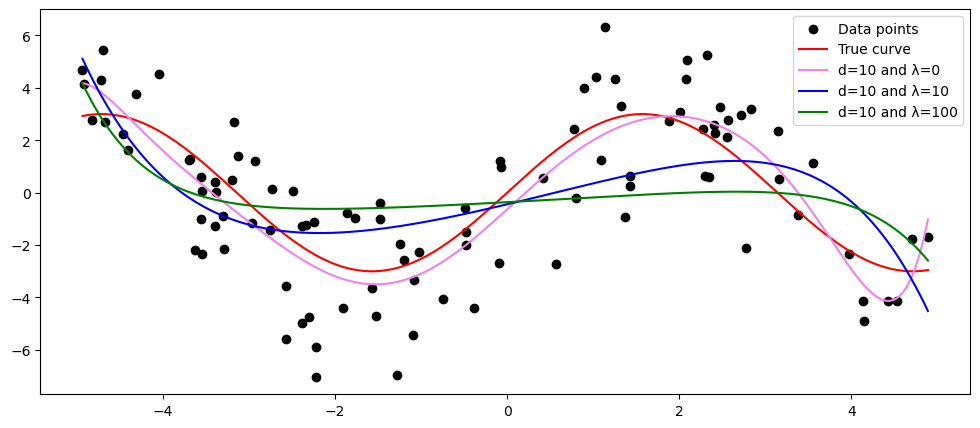

In [389]:
# 0. Generate data
np.random.seed(2016) # for reproducibility of random numbers
n = 100 # sample size
x = np.random.uniform(-5,5,n)
error = np.random.normal(0,2,n)
y = 3*np.sin(x) + error

# 1. Create Polynomial Features
degree = 10 # highest polynomial degree
poly = PolynomialFeatures(degree=degree,include_bias=False)
poly = poly.fit(x.reshape(n,1)) # better to fit and transform individually for later predictions
X_poly = poly.transform(x.reshape(n,1)) # design matrix without intercept


# 2. Scale features
scale = StandardScaler().fit(X_poly) # better to fit and transform individually for later predictions
X_scale = scale.transform(X_poly) # standardised features
X_scale_design = np.column_stack((np.ones(n),X_scale)) # design matrix with standardised features and intercept

# 3. Compute Ridge manually for different lambda values
lambdas = [0,10,100]
theta_hats_manual = []
for lbda in lambdas:
    I = np.eye(X_scale_design.shape[1])
    I[0,0] = 0 # do not penalize intercept
    theta_hat_manual = np.linalg.inv(X_scale_design.T @ X_scale_design + lbda*I) @ X_scale_design.T @ y
    theta_hats_manual.append(list(theta_hat_manual))


columns = ["θ_" + str(i) for i in range(11)] 
rows = ["λ="+ str(lbda) for lbda in lambdas]
theta_hats_manual_df=pd.DataFrame(theta_hats_manual,columns=columns,index=rows)
print("theta_hats_manual_df:\n",theta_hats_manual_df)


# 3. Compute Ridge with library for different lambda values
theta_hats_library = []
for lbda in lambdas:
    model_ridge = Ridge(alpha=lbda,fit_intercept=True).fit(X_scale,y)
    theta_hat_library = [model_ridge.intercept_,*model_ridge.coef_]
    theta_hats_library.append(theta_hat_library)


theta_hats_library_df=pd.DataFrame(theta_hats_library,columns=columns,index=rows)
print("theta_hats_library_df:\n",theta_hats_library_df)



# Plot data
plt.figure(figsize=(12,5))
plt.scatter(x,y,color="black",label="Data points")
x_line=np.linspace(np.min(x),np.max(x),200)
plt.plot(x_line,3*np.sin(x_line),color="red",label="True curve")

colors=["violet","blue","green"]

X_line_poly = poly.transform(x_line.reshape(-1,1))  # polynomial features
X_line_scaled = scale.transform(X_line_poly)  


for lbda, clr in zip(lambdas, colors):
    model_ridge = Ridge(alpha=lbda, fit_intercept=True).fit(X_scale, y)
    y_hat_line = model_ridge.predict(X_line_scaled)  # predict on smooth x_line
    plt.plot(x_line, y_hat_line, color=clr, label=f"d=10 and λ={lbda}")

plt.legend()
plt.show()

### Ridge Regression with Centered Response

Ridge regression solves:

$$
\hat{\theta} = \arg\min_\theta \|y - X \theta\|^2 + \lambda \|\theta\|^2
$$

#### 1. Center the response
$$
y_c = y - \bar{y}
$$

This allows us to **penalize all coefficients** without affecting the intercept.

#### 2. Solve ridge for coefficients
$$
\hat{\beta} = (X_c^\top X_c + \lambda I)^{-1} X_c^\top y_c
$$

- $X_c = X$ if predictors are already standardized.
- $\mathrm{I}$ is the identity matrix (size = number of features).

#### 3. Recover intercept
$$
\hat{\theta}_0 = \bar{y} - \bar{X} \cdot \hat{\beta}
$$

- Ensures the intercept is **not shrunk**, matching `sklearn.Ridge(fit_intercept=True)`.

#### 4. Predict
$$
\hat{y} = \hat{\theta}_0 + X \hat{\beta}
$$

✅ Centering `y` is the key trick to simplify ridge and understand scikit-learn's Ridge implementation.

theta_hats_manual_df:
             θ_0       θ_1       θ_2        θ_3        θ_4       θ_5  \
λ=0   -0.110419  8.803523  6.876168 -21.781577 -53.650488  9.650031   
λ=10  -0.110419  1.510664 -0.015794  -1.271759  -0.080470 -0.986667   
λ=100 -0.110419  0.227618 -0.014139  -0.270295  -0.009928 -0.324773   

              θ_6        θ_7         θ_8       θ_9       θ_10  
λ=0    142.526640  12.856081 -155.635002 -9.960516  60.170270  
λ=10    -0.030846  -0.359562    0.044609  0.180221   0.148269  
λ=100    0.004050  -0.293281    0.017806 -0.249597   0.032213  
theta_hats_library_df:
             θ_0       θ_1       θ_2        θ_3        θ_4       θ_5  \
λ=0   -0.110419  8.803523  6.876168 -21.781577 -53.650488  9.650031   
λ=10  -0.110419  1.510664 -0.015794  -1.271759  -0.080470 -0.986667   
λ=100 -0.110419  0.227618 -0.014139  -0.270295  -0.009928 -0.324773   

              θ_6        θ_7         θ_8       θ_9       θ_10  
λ=0    142.526640  12.856081 -155.635002 -9.960516  60.170270  

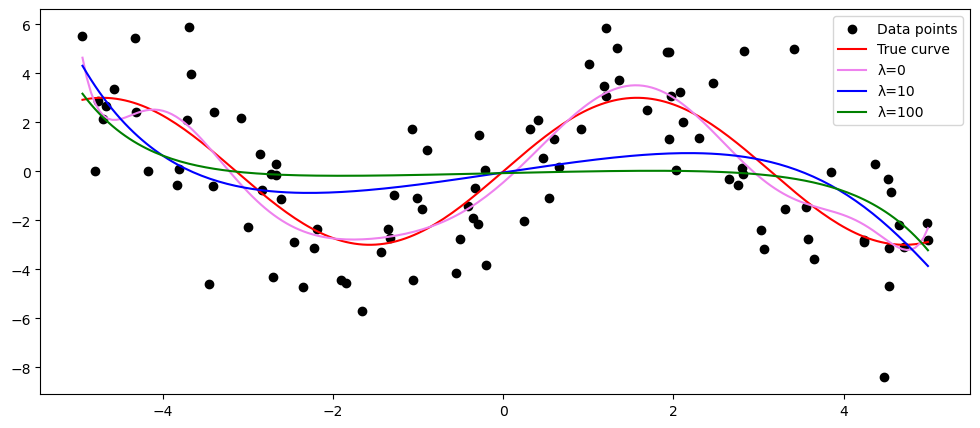

In [392]:
# 0. Generate data
np.random.seed(2144)  # for reproducibility of random numbers
n = 100  # sample size
x = np.random.uniform(-5,5,n)
error = np.random.normal(0,2,n)
y = 3*np.sin(x) + error

# 1. Create Polynomial Features
degree = 10  # highest polynomial degree
poly = PolynomialFeatures(degree=degree, include_bias=False)
poly = poly.fit(x.reshape(n,1))  # fit for later predictions
X_poly = poly.transform(x.reshape(n,1))  # design matrix without intercept

# 2. Scale features
scale = StandardScaler().fit(X_poly)  # fit for later predictions
X_scale = scale.transform(X_poly)  # standardized features
X_scale_design = np.column_stack((np.ones(n), X_scale))  # design matrix with intercept

# 3. Compute Ridge manually with centered y to match sklearn
lambdas = [0,10,100]
theta_hats_manual = []

y_centered = y - y.mean()  # center y
for lbda in lambdas:
    I = np.eye(X_scale.shape[1]) # penalizing intercept as well now
    theta_centered = np.linalg.inv(X_scale.T @ X_scale + lbda*I) @ (X_scale.T @ y_centered)
    intercept = y.mean() - X_scale.mean(axis=0) @ theta_centered  # recover intercept
    theta_hats_manual.append([intercept, *theta_centered])

# 4. Create DataFrame for manual coefficients
columns = ["θ_" + str(i) for i in range(11)]
rows = ["λ="+ str(lbda) for lbda in lambdas]
theta_hats_manual_df = pd.DataFrame(theta_hats_manual, columns=columns, index=rows)
print("theta_hats_manual_df:\n", theta_hats_manual_df)

# 5. Compute Ridge with library for comparison
theta_hats_library = []
for lbda in lambdas:
    model_ridge = Ridge(alpha=lbda, fit_intercept=True).fit(X_scale, y)
    theta_hat_library = [model_ridge.intercept_, *model_ridge.coef_]
    theta_hats_library.append(theta_hat_library)

theta_hats_library_df = pd.DataFrame(theta_hats_library, columns=columns, index=rows)
print("theta_hats_library_df:\n", theta_hats_library_df)

# 6. Plot data and predictions
plt.figure(figsize=(12,5))
plt.scatter(x, y, color="black", label="Data points")
x_line = np.linspace(np.min(x), np.max(x), 200)
plt.plot(x_line, 3*np.sin(x_line), color="red", label="True curve")

colors = ["violet", "blue", "green"]

# Transform x_line for prediction
X_line_poly = poly.transform(x_line.reshape(-1,1))
X_line_scaled = scale.transform(X_line_poly)

for lbda, clr in zip(lambdas, colors):
    model_ridge = Ridge(alpha=lbda, fit_intercept=True).fit(X_scale, y)
    y_hat_line = model_ridge.predict(X_line_scaled)
    plt.plot(x_line, y_hat_line, color=clr, label=f"λ={lbda}")

plt.legend()
plt.show()

<a class="anchor" id="gd1"></a>
## 1.7 Gradient Descent 

<a class="anchor" id="sgd1"></a>
## 1.8 Stochastic Gradient Descent 

<a class="anchor" id="lasso"></a>
## 2. Lasso Regression 

<a class="anchor" id="derive2"></a>
## 2.1 Derivation 


<div style="display:flex; gap:20px;">

<!--  -->
<div style="
padding:16px;
border-radius:8px;
width:50%;
">


<h5 style="text-align:center;"><u>Analytical solution</u></h5>

**Goal:** Find parameter vector $\hat{\theta} \in \mathbb{R}^{p+1}$ by finding parameter vector $\theta \in \mathbb{R}^{p+1}$
that minimizes sum of squared errors and regulates size of coefficients $\theta_0,\ldots,\theta_p$ via an $\ell_1$ penalty.

$$
\begin{align*}
& \arg \min_{\theta \in \mathbb{R}^{p+1}} & \lVert y - X\theta \rVert_2^2 \\
& \text{s.t.} & \lVert \theta \rVert_1 \le t   \\
& \iff & \lVert \theta \rVert_1 - t \le 0 
\end{align*}
$$

Lagrangian

$$
\begin{align*}
\mathcal{L}(\theta,\lambda) 
&= \lVert y - X\theta \rVert_2^2 + \lambda (\lVert \theta \rVert_1 - t)  \\
&= (y - X\theta)^\top (y - X\theta) + \lambda \sum_{j=0}^{p} |\theta_j|
\end{align*}
$$

Take gradient and set to 0

$$
\begin{align*}
-2X^\top y + 2X^\top X\theta + \lambda \cdot \text{sign}(\theta) = 0
\end{align*}
$$

- $\text{sign}(\theta_j) \in \{-1,1\}$ if $\theta_j \neq 0$
- $\text{sign}(\theta_j) \in [-1,1]$ if $\theta_j = 0$

---

$$
\Rightarrow \text{No closed-form solution in general}
$$

- Must be solved using numerical optimization (e.g. coordinate descent)

</div>


<!--  -->
<div style="
padding:16px;
border-radius:8px;
width:50%;
">

<h5 style="text-align:center;"><u>Bayesian statistics</u></h5>

**Goal:** Find parameter vector $\hat{\theta} \in \mathbb{R}^{p+1}$ by maximizing the Posterior distribution $p(\theta \mid y,X)$.

$$
\text{Likelihood: }y \mid X,\theta \sim \mathcal{N}(X\theta, \sigma^2\mathrm{I}_{n\times n})
$$

$$
\text{Prior: } p(\theta) \propto \exp\left(-\frac{1}{b}\lVert \theta \rVert_1 \right)
$$

---

$$
\begin{align*}
\hat{\theta} 
&= \arg \max_{\theta \in \mathbb{R}^{p+1}} p(\theta \mid y,X) \\
&= \arg \max_{\theta \in \mathbb{R}^{p+1}} p(y \mid X,\theta)p(\theta)
\end{align*}
$$ 

---

$$
\begin{align*}
p(y \mid X,\theta)
&\propto \exp\left(-\frac{1}{2\sigma^2} (y-X\theta)^\top(y-X\theta)\right)
\end{align*}
$$

---

$$
\begin{align*}
p(\theta)
&\propto \exp\left(-\frac{1}{b} \lVert \theta \rVert_1 \right)
\end{align*}
$$

---

Take logarithm

$$
\begin{align*}
&= \arg \max_{\theta \in \mathbb{R}^{p+1}} \log p(y \mid X,\theta) + \log p(\theta) \\
&= \arg \max_{\theta \in \mathbb{R}^{p+1}} -\frac{1}{2\sigma^2} \lVert y-X\theta \rVert_2^2 - \frac{1}{b} \lVert \theta \rVert_1 \\
&= \arg \min_{\theta \in \mathbb{R}^{p+1}} \frac{1}{2\sigma^2} \lVert y-X\theta \rVert_2^2 + \frac{1}{b} \lVert \theta \rVert_1
\end{align*}
$$ 

---

Rescale

$$
\begin{align*}
&= \arg \min_{\theta \in \mathbb{R}^{p+1}} \lVert y-X\theta \rVert_2^2 + \lambda \lVert \theta \rVert_1 \\
&\hspace{2.5 cm} \text{where } \lambda := \frac{2\sigma^2}{b}
\end{align*}
$$ 

---

$$
\Rightarrow \hat{\theta}
= \arg \min_{\theta \in \mathbb{R}^{p+1}} \lVert y-X\theta \rVert_2^2 + \lambda \lVert \theta \rVert_1
$$

---

$$
\Rightarrow \text{Lasso = MAP estimator with Laplace prior}
$$

</div>

</div>

<a class="anchor" id="geom2"></a>
## 2.2 Geometry of Lasso Regression 

<a class="anchor" id="implement2"></a>
## 2.3 Implementation 

<a class="anchor" id="scale2"></a>
## 2.4 Feature scaling 

- We could arbitrarily force a feature out of the model through a unit change

<a class="anchor" id="corr2"></a>
## 2.5 Arbitrary Feature Selection for correlated Features 

<a class="anchor" id="gd2"></a>
## 2.6 Gradient Descent 

<a class="anchor" id="sgd2"></a>
## 2.7 Stochastic Gradient Descent 